## 0 · Install dependencies

In [1]:
!pip install torch torchvision nibabel pandas scikit-learn tqdm matplotlib scipy optuna -q

## 1 · Imports

In [17]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm.notebook import tqdm

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 34
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU   : NVIDIA GeForce RTX 3090
VRAM  : 25.4 GB


## 2 · Configuration

> **Memory guide**
> | `TARGET_SHAPE` | VRAM (BS=4) |
> |---|---|
> | `(32,32,32)` | ~2 GB |
> | `(64,64,64)` | ~6 GB |
> | `(96,96,96)` | ~14 GB |


In [2]:
CSV_PATH     = "OASIS3_metadata_final.csv"
IMAGE_DIR    = "."

TARGET_SHAPE = (96, 96, 96)   # (D, H, W)

# Optuna settings
N_TRIALS          = 30    # number of hyperparameter combinations to try
EPOCHS_PER_TRIAL  = 5    # quick epochs per trial to compare candidates
EPOCHS_FINAL      = 50    # full training with the best hyperparams

## 3 · Load metadata & create labels

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Raw CSV rows: {len(df)}")

df["label"] = df["DEMENTED"].astype(int)
df = df[(df["DEMENTED"] + df["NORMCOG"]) == 1]
print(f"After consistency filter: {len(df)}")

display(df[["Subject_ID", "DEMENTED", "NORMCOG", "label"]].head())
print("\nLabel distribution:")
display(df["label"].value_counts().rename({0: "Normal", 1: "Demented"}))

Raw CSV rows: 1086
After consistency filter: 1086


,Subject_ID,DEMENTED,NORMCOG,label
0,OAS30001,0,1,0
1,OAS30002,0,1,0
2,OAS30003,0,1,0
3,OAS30004,0,1,0
4,OAS30005,0,1,0



Label distribution:


label
Normal      686
Demented    400
Name: count, dtype: int64

## 4 · Match subjects → NIfTI files

In [4]:
all_images = glob.glob(os.path.join(IMAGE_DIR, "**/*.nii.gz"), recursive=True)
print(f"NIfTI files found: {len(all_images)}")

subject_to_path = {}
for img_path in all_images:
    filename = os.path.basename(img_path)
    for subject_id in df["Subject_ID"].unique():
        if subject_id in filename:
            subject_to_path[subject_id] = img_path
            break

df["image_path"] = df["Subject_ID"].map(subject_to_path)
missing = df["image_path"].isna().sum()
print(f"Subjects without MRI: {missing}")
df = df.dropna(subset=["image_path"])
print(f"Final dataset size  : {len(df)}")

NIfTI files found: 1188
Subjects without MRI: 0
Final dataset size  : 1086


## 5 · Train / Validation / Test split  (60 / 20 / 20)

In [5]:
# Stratify by label + age bin + gender to ensure balanced distributions:
df["age_bin"] = (df["Age"] >= 75).astype(int)
df["strat"]   = (
    df["label"].astype(str) + "_" +
    df["age_bin"].astype(str) + "_" +
    df["Gender"].astype(str)   # 1 = male, 2 = female
)

print("Stratum distribution:\n", df["strat"].value_counts())

train_df, temp_df = train_test_split(
    df, test_size=0.4, stratify=df["strat"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["strat"], random_state=SEED
)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n── {name} ──")
    print(split["label"].value_counts(normalize=True).rename({0: "Normal", 1: "Demented"}))
    print(f"Age mean : {split['Age'].mean():.1f}  std: {split['Age'].std():.1f}")
    print(f"Gender   : {split['Gender'].value_counts(normalize=True).rename({1: 'Male', 2: 'Female'}).to_dict()}")

Stratum distribution:
 strat
0_0_2    343
0_0_1    235
1_1_1    119
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64

Train: 651  |  Val: 217  |  Test: 218
Total: 1086

── Train ──
label
Normal      0.632873
Demented    0.367127
Name: proportion, dtype: float64
Age mean : 70.7  std: 9.2
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}

── Val ──
label
Normal      0.631336
Demented    0.368664
Name: proportion, dtype: float64
Age mean : 70.2  std: 9.6
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}

── Test ──
label
Normal      0.62844
Demented    0.37156
Name: proportion, dtype: float64
Age mean : 70.1  std: 9.1
Gender   : {'Female': 0.5458715596330275, 'Male': 0.4541284403669725}


## 6 · Dataset class

In [6]:
def load_and_preprocess(path, target_shape=TARGET_SHAPE):
    nii    = nib.load(path)
    volume = nii.get_fdata(dtype=np.float32)
    volume = np.squeeze(volume)
    zoom_factors = [t / s for t, s in zip(target_shape, volume.shape)]
    volume = zoom(volume, zoom_factors, order=1)
    vmin, vmax = volume.min(), volume.max()
    return (volume - vmin) / (vmax - vmin + 1e-8)


class OASIS3DDataset(Dataset):
    def __init__(self, dataframe, target_shape=TARGET_SHAPE, augment=False):
        self.df           = dataframe.reset_index(drop=True)
        self.target_shape = target_shape
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        volume = load_and_preprocess(row["image_path"], self.target_shape)

        if self.augment:
            if random.random() > 0.5:
                volume = np.flip(volume, axis=0).copy()
            if random.random() > 0.5:
                volume = np.clip(volume + np.random.normal(0, 0.01, volume.shape), 0, 1)

        volume = torch.tensor(volume, dtype=torch.float32).unsqueeze(0)
        label  = torch.tensor(row["label"], dtype=torch.long)
        return volume, label

## 7 · 3D CNN — Parametric Architecture

The model accepts hyperparameters suggested by Optuna:

| Parameter | Search space |
|---|---|
| `base_channels` | 16, 32, 64 |
| `n_blocks` | 3 or 4 conv stages |
| `fc_units` | 64 – 512 |
| `dropout` | 0.1 – 0.6 |
| `lr` | 1e-5 – 1e-3 (log scale) |
| `batch_size` | 2, 4, 8 |
| `augment` | True / False |


In [11]:
class Conv3DBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Net(nn.Module):
    def __init__(self, encoder, gap, classifier):
        super().__init__()
        self.encoder = encoder
        self.gap = gap
        self.classifier = classifier

    def forward(self, x):
        return self.classifier(self.gap(self.encoder(x)))


def build_model(config):
    base = config["base_channels"]
    channels = [base * (2 ** i) for i in range(config["n_blocks"])]

    layers = []
    in_ch = 1

    for out_ch in channels:
        layers += [
            Conv3DBlock(in_ch, out_ch),
            nn.MaxPool3d(2)
        ]
        in_ch = out_ch

    encoder = nn.Sequential(*layers)
    gap = nn.AdaptiveAvgPool3d(1)

    fc_layers = []
    in_features = channels[-1]

    for _ in range(config["n_fc_layers"]):
        fc_layers += [
            nn.Linear(in_features, config["fc_units"]),
            nn.ReLU(inplace=True),
            nn.Dropout(config["dropout"]),
        ]
        in_features = config["fc_units"]

    # ✔ FINAL LAYER CHANGED: 1 → 2 classes
    fc_layers.append(nn.Linear(in_features, 2))

    classifier = nn.Sequential(nn.Flatten(), *fc_layers)

    return Net(encoder, gap, classifier).to(DEVICE)

## 8 · Training & Evaluation


In [7]:
import copy


def train_model(model, train_loader, val_loader, epochs, lr, criterion, device,
                scheduler_name="ReduceLROnPlateau", patience=15, min_delta=0.0, plots=True, verbose=True):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    if scheduler_name == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=3
        )
    elif scheduler_name == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs
        )
    else:
        scheduler = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_auc": [],
    }

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in tqdm(range(epochs), desc="Epochs"):

        model.train()
        train_correct = 0
        train_total = 0
        epoch_t_loss = 0.0

        for volumes, labels in train_loader:
            volumes = volumes.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(volumes)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_t_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            train_total += labels.size(0)
            train_correct += (preds == labels).sum().item()

        epoch_train_acc = 100 * train_correct / train_total
        epoch_train_loss = epoch_t_loss / len(train_loader)

        history["train_acc"].append(epoch_train_acc)
        history["train_loss"].append(epoch_train_loss)

        model.eval()

        val_correct = 0
        val_total = 0
        epoch_v_loss = 0.0
        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for volumes, labels in val_loader:
                volumes = volumes.to(device)
                labels = labels.to(device).long()

                outputs = model(volumes)
                loss = criterion(outputs, labels)
                epoch_v_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                probs = torch.softmax(outputs, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())

        epoch_val_acc = 100 * val_correct / val_total
        epoch_val_loss = epoch_v_loss / len(val_loader)

        epoch_val_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_auc = roc_auc_score(all_labels, all_probs)

        history["val_acc"].append(epoch_val_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_precision"].append(epoch_val_precision)
        history["val_recall"].append(epoch_val_recall)
        history["val_f1"].append(epoch_val_f1)
        history["val_auc"].append(epoch_val_auc)

        if scheduler_name == "ReduceLROnPlateau" and scheduler is not None:
            scheduler.step(epoch_val_loss)
        elif scheduler_name == "CosineAnnealingLR" and scheduler is not None:
            scheduler.step()

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print("\nEarly stopping triggered!")
                break

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.2f}% | "
                f"Val Acc: {epoch_val_acc:.2f}% | "
                f"Val Precision: {epoch_val_precision*100:.2f}% | "
                f"Val Recall: {epoch_val_recall*100:.2f}% | "
                f"Val F1: {epoch_val_f1*100:.2f}%"
            )

    def plot_accuracies(history):
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_acc"], label="Train Accuracy", marker="o")
        plt.plot(history["val_acc"], label="Validation Accuracy", marker="o")
        plt.title("Model Accuracy", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Accuracy (%)", fontsize=12)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_losses(history):
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_loss"], label="Train Loss", marker="o")
        plt.plot(history["val_loss"], label="Validation Loss", marker="o")
        plt.title("Model Loss", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Loss", fontsize=12)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_precision(val_precision):
        plt.figure(figsize=(8, 5))
        plt.plot(val_precision, marker="o")
        plt.title("Validation Precision", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Precision", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_recall(val_recall):
        plt.figure(figsize=(8, 5))
        plt.plot(val_recall, marker="o")
        plt.title("Validation Recall", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Recall", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    def plot_f1(val_f1):
        plt.figure(figsize=(8, 5))
        plt.plot(val_f1, marker="o")
        plt.title("Validation F1-Score", fontsize=20)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("F1-Score", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

    if plots:
        plot_accuracies(history)
        plot_losses(history)
        plot_precision(history["val_precision"])
        plot_recall(history["val_recall"])
        plot_f1(history["val_f1"])

    model.load_state_dict(best_model_weights)
    return model, history


def test_model(model, test_loader, device, plot=True, save=False):

    model.eval()
    preds = []
    trues = []
    probs = []

    with torch.no_grad():
        for volumes, labels in test_loader:
            volumes = volumes.to(device)
            labels = labels.to(device).long()

            outputs = model(volumes)

            pr = torch.argmax(outputs, dim=1)
            p = torch.softmax(outputs, dim=1)[:, 1]

            preds.extend(pr.cpu().numpy())
            trues.extend(labels.cpu().numpy())
            probs.extend(p.cpu().numpy())

    trues = np.array(trues)
    preds = np.array(preds)
    probs = np.array(probs)

    acc = accuracy_score(trues, preds)
    precision_macro = precision_score(trues, preds, average="macro", zero_division=0)
    precision_weighted = precision_score(trues, preds, average="weighted", zero_division=0)
    recall_macro = recall_score(trues, preds, average="macro", zero_division=0)
    recall_weighted = recall_score(trues, preds, average="weighted", zero_division=0)
    f1_macro = f1_score(trues, preds, average="macro", zero_division=0)
    f1_weighted = f1_score(trues, preds, average="weighted", zero_division=0)
    auc_score = roc_auc_score(trues, probs)

    print("\n===== TEST METRICS =====")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Macro Precision    : {precision_macro:.4f}")
    print(f"Weighted Precision : {precision_weighted:.4f}")
    print(f"Macro Recall       : {recall_macro:.4f}")
    print(f"Weighted Recall    : {recall_weighted:.4f}")
    print(f"Macro F1-score     : {f1_macro:.4f}")
    print(f"Weighted F1-score  : {f1_weighted:.4f}")
    print(f"ROC AUC            : {auc_score:.4f}")

    labels_names = ["Normal", "Demented"]

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(trues, preds, target_names=labels_names, digits=4))

    if plot:
        cm = confusion_matrix(trues, preds, labels=[0, 1])
        cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names
        )
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.tight_layout()

        if save:
            plt.savefig("confusion_matrix_test.png", dpi=300, bbox_inches="tight")

        plt.show()

        fpr, tpr, _ = roc_curve(trues, probs)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.title("ROC Curve")
        plt.tight_layout()

        if save:
            plt.savefig("roc_curve_test.png", dpi=300, bbox_inches="tight")

        plt.show()

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "auc": auc_score,
        "confusion_matrix": confusion_matrix(trues, preds, labels=[0, 1])
    }

## 9 · Optuna Objective Function

An Optuna study is defined to approximate the optimal model configuration by maximizing the macro F1 score on the validation set. This metric considers both classes (Normal and Demented) equally, ensuring balanced performance and mitigating the effects of class imbalance during hyperparameter optimization.

### Define Optuna Study


In [10]:
def objective(trial):

    ### 1. Hyperparameters ###

    base_channels = trial.suggest_categorical("base_channels", [16, 32, 64])
    n_blocks      = trial.suggest_int("n_blocks", 3, 4)
    n_fc_layers   = trial.suggest_int("n_fc_layers", 0, 2)
    fc_units      = trial.suggest_int("fc_units", 64, 512, step=64)
    dropout       = trial.suggest_float("dropout", 0.1, 0.6)
    batch_size    = trial.suggest_categorical("batch_size", [2, 4, 8])
    lr            = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    ### 2. Build model ###

    config = {
        "base_channels": base_channels,
        "n_blocks": n_blocks,
        "n_fc_layers": n_fc_layers,
        "fc_units": fc_units,
        "dropout": dropout,
    }

    try:
        model = build_model(config)
    except RuntimeError:
        raise optuna.exceptions.TrialPruned()

    ### 3. Loss / optimizer / scheduler ###

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.1, patience=2
    )

    ### 4. DataLoaders ###

    train_loader = DataLoader(
        OASIS3DDataset(train_df, augment=False),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
    )

    val_loader = DataLoader(
        OASIS3DDataset(val_df, augment=False),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )

    ### 5. Training loop ###

    val_f1_history = []

    print(f"\nTrial {trial.number} | "
          f"bs={batch_size}, lr={lr:.2e}, blocks={n_blocks}, "
          f"fc_layers={n_fc_layers}, fc_units={fc_units}, drop={dropout:.2f}")

    for epoch in tqdm(range(EPOCHS_PER_TRIAL), desc=f"Trial {trial.number}", leave=False):

        # TRAIN
        model.train()

        for volumes, labels in train_loader:
            volumes = volumes.to(DEVICE)
            labels  = labels.to(DEVICE).long()

            optimizer.zero_grad()
            logits = model(volumes)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()

        all_preds, all_labels, all_probs = [], [], []
        val_loss = 0.0

        with torch.no_grad():
            for volumes, labels in val_loader:
                volumes = volumes.to(DEVICE)
                labels  = labels.to(DEVICE).long()

                logits = model(volumes)
                val_loss += criterion(logits, labels).item()

                probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                preds = np.argmax(logits.cpu().numpy(), axis=1)

                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        # METRICS
        epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        val_f1_history.append(epoch_f1)

        scheduler.step(val_loss)

        trial.report(epoch_f1, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    ### 6. Return mean of last 5 epochs F1 ###

    score = np.mean(val_f1_history[-5:])
    print(f"Trial {trial.number} finished | F1 (mean last 5): {score:.4f}")

    return score

### Run Optuna Study

Once the Optuna study is defined, a total of `N_TRIALS` trials are conducted, each corresponding to a different model configuration with varying architectural and training hyperparameters. Each trial is evaluated by maximizing the macro-averaged F1 score on the validation set.


In [11]:
# Create a run of the defined Optuna study:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # trial-level output handled manually

def trial_callback(study, trial):
    """Print a one-liner summary after each completed trial."""
    if trial.state == optuna.trial.TrialState.COMPLETE:
        best_so_far = study.best_value
        marker = " ◀ NEW BEST" if abs(trial.value - best_so_far) < 1e-9 else ""
        print(f"  ✓ Trial {trial.number + 1:>3}/{N_TRIALS} | "
              f"F1={trial.value:.4f} | best so far={best_so_far:.4f}{marker}")
    elif trial.state == optuna.trial.TrialState.PRUNED:
        print(f"  ✗ Trial {trial.number + 1:>3}/{N_TRIALS} | PRUNED")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, callbacks=[trial_callback])

print(f"\n{'='*50}")
print(f"Best trial  : #{study.best_trial.number + 1}")
print(f"Best val F1 : {study.best_value:.4f}")
print(f"Best params :")
for k, v in study.best_params.items():
    print(f"  {k:<20} = {v}")



Trial 0 | bs=4, lr=2.06e-03, blocks=3, fc_layers=0, fc_units=64, drop=0.30


Trial 0:   0%|          | 0/5 [00:00<?, ?it/s]

Trial 0 finished | F1 (mean last 5): 0.3870
  ✓ Trial   1/30 | F1=0.3870 | best so far=0.3870 ◀ NEW BEST

Trial 1 | bs=8, lr=3.13e-03, blocks=4, fc_layers=1, fc_units=256, drop=0.42


Trial 1:   0%|          | 0/5 [00:00<?, ?it/s]

Trial 1 finished | F1 (mean last 5): 0.3870
  ✓ Trial   2/30 | F1=0.3870 | best so far=0.3870 ◀ NEW BEST

Trial 2 | bs=4, lr=5.16e-03, blocks=4, fc_layers=2, fc_units=256, drop=0.41


...

Trial 27 finished | F1 (mean last 5): 0.5102
  ✓ Trial  28/30 | F1=0.5102 | best so far=0.6083

Trial 28 | bs=2, lr=2.42e-04, blocks=4, fc_layers=1, fc_units=384, drop=0.32


Trial 28:   0%|          | 0/5 [00:00<?, ?it/s]

  ✗ Trial  29/30 | PRUNED

Trial 29 | bs=8, lr=6.55e-04, blocks=4, fc_layers=0, fc_units=256, drop=0.49


Trial 29:   0%|          | 0/5 [00:00<?, ?it/s]

  ✗ Trial  30/30 | PRUNED

Best trial  : #7
Best val F1 : 0.6083
Best params :
  base_channels        = 32
  n_blocks             = 4
  n_fc_layers          = 1
  fc_units             = 384
  dropout              = 0.3302452741076105
  batch_size           = 4
  lr                   = 0.00012556631685139573


## 10 · Optuna Visualizations


In [12]:
# fig1 = plot_optimization_history(study)
# fig1.update_layout(title="Optimization History — Val F1")
# fig1.show()

# fig2 = plot_param_importances(study)
# fig2.update_layout(title="Hyperparameter Importances")
# fig2.show()

# fig3 = plot_parallel_coordinate(study)
# fig3.update_layout(title="Parallel Coordinate Plot")
# fig3.show()

## 11 · Final Training with Best Hyperparameters

Once the Optuna study concludes, the best configuration is used to train the model for the full `EPOCHS_FINAL` epochs using `train_model`.


In [13]:
# best_params = {
#     "base_channels": 32,
#     "n_blocks": 3,
#     "n_fc_layers": 1,
#     "fc_units": 192,
#     "dropout": 0.42844504506134384,
#     "batch_size": 8,
#     "lr": 0.00015123274844778766,
# }

In [14]:
best_params = study.best_params
print("Training with:", best_params)

final_config = {
    "base_channels": best_params["base_channels"],
    "n_blocks": best_params["n_blocks"],
    "n_fc_layers": best_params["n_fc_layers"],
    "fc_units": best_params["fc_units"],
    "dropout": best_params["dropout"],
}

final_model = build_model(final_config)

n_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

final_criterion = nn.CrossEntropyLoss()

final_train_loader = DataLoader(
    OASIS3DDataset(train_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

final_val_loader = DataLoader(
    OASIS3DDataset(val_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

final_test_loader = DataLoader(
    OASIS3DDataset(test_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Training with: {'base_channels': 32, 'n_blocks': 4, 'n_fc_layers': 1, 'fc_units': 384, 'dropout': 0.3302452741076105, 'batch_size': 4, 'lr': 0.00012556631685139573}
Trainable parameters: 3,613,538


In [15]:
from torchinfo import summary
summary(final_model)

Layer (type:depth-idx)                   Param #
Net                                      --
├─Sequential: 1-1                        --
│    └─Conv3DBlock: 2-1                  --
│    │    └─Sequential: 3-1              28,640
│    └─MaxPool3d: 2-2                    --
│    └─Conv3DBlock: 2-3                  --
│    │    └─Sequential: 3-2              166,144
│    └─MaxPool3d: 2-4                    --
│    └─Conv3DBlock: 2-5                  --
│    │    └─Sequential: 3-3              664,064
│    └─MaxPool3d: 2-6                    --
│    └─Conv3DBlock: 2-7                  --
│    │    └─Sequential: 3-4              2,655,232
│    └─MaxPool3d: 2-8                    --
├─AdaptiveAvgPool3d: 1-2                 --
├─Sequential: 1-3                        --
│    └─Flatten: 2-9                      --
│    └─Linear: 2-10                      98,688
│    └─ReLU: 2-11                        --
│    └─Dropout: 2-12                     --
│    └─Linear: 2-13                      770
T

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 0.6588 | Val Loss: 0.8588 | Train Acc: 62.06% | Val Acc: 39.63% | Val Precision: 62.65% | Val Recall: 51.93% | Val F1: 32.16%
Epoch 2/50 | Train Loss: 0.6050 | Val Loss: 0.8945 | Train Acc: 66.51% | Val Acc: 45.16% | Val Precision: 65.45% | Val Recall: 56.05% | Val F1: 40.94%
Epoch 3/50 | Train Loss: 0.5963 | Val Loss: 0.8772 | Train Acc: 68.82% | Val Acc: 63.13% | Val Precision: 31.57% | Val Recall: 50.00% | Val F1: 38.70%
Epoch 4/50 | Train Loss: 0.5886 | Val Loss: 0.7005 | Train Acc: 69.74% | Val Acc: 67.74% | Val Precision: 83.09% | Val Recall: 56.25% | Val F1: 50.94%
Epoch 5/50 | Train Loss: 0.5601 | Val Loss: 1.3139 | Train Acc: 71.27% | Val Acc: 37.79% | Val Precision: 68.60% | Val Recall: 50.73% | Val F1: 28.56%
Epoch 6/50 | Train Loss: 0.5504 | Val Loss: 0.7914 | Train Acc: 71.58% | Val Acc: 53.46% | Val Precision: 67.42% | Val Recall: 62.10% | Val F1: 52.14%
Epoch 7/50 | Train Loss: 0.5608 | Val Loss: 0.5547 | Train Acc: 69.12% | Val Acc: 70.51% | Val

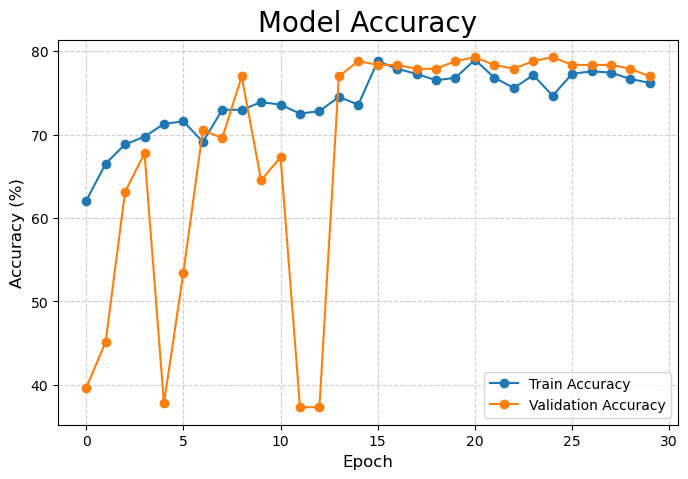

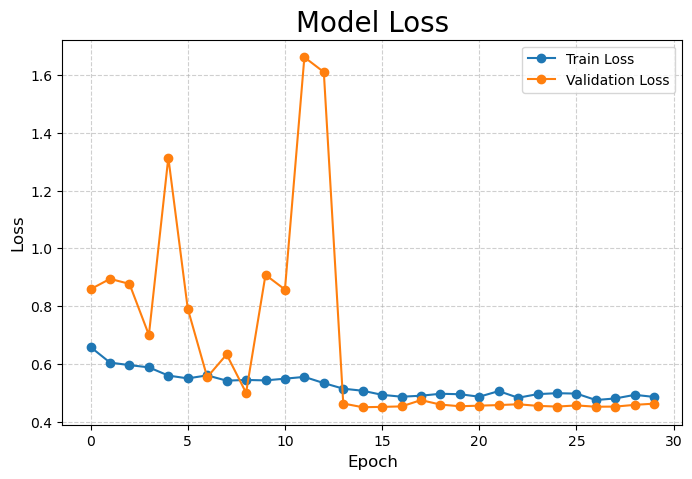

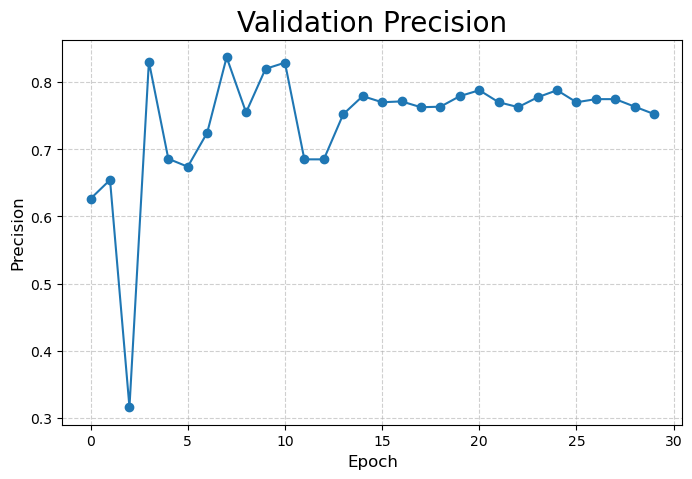

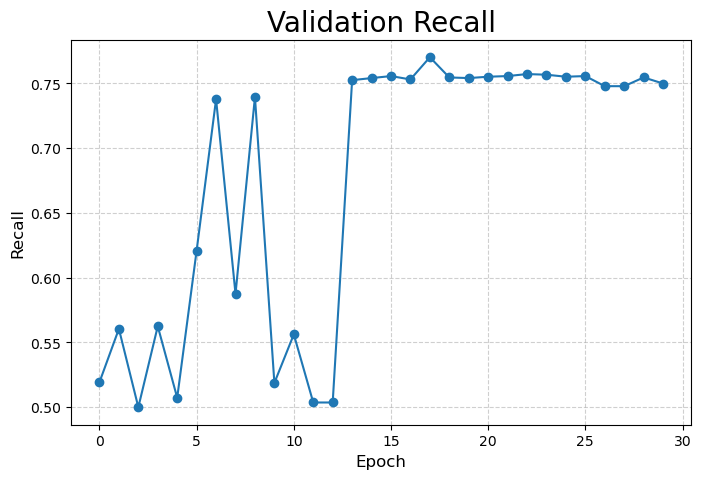

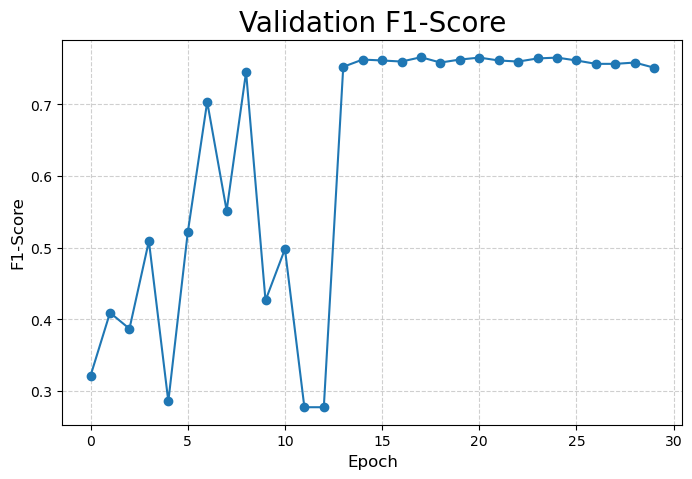

Best model saved to best_alzheimer3dcnn_optunaT1.pth


In [16]:
# Train the final model using the best hyperparameters:
final_model, final_history = train_model(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    epochs=EPOCHS_FINAL,
    lr=best_params["lr"],
    criterion=final_criterion,
    device=DEVICE,
    scheduler_name="ReduceLROnPlateau",
    patience=15,
    plots=True,
    verbose=True
)

# Save best model checkpoint:
torch.save(final_model.state_dict(), "best_alzheimer3dcnn_optunaT1.pth")
print("Best model saved to best_alzheimer3dcnn_optunaT1.pth")


## 12 · Test Set Evaluation


In [15]:

# =========================================================
# Best Optuna hyperparameters
# =========================================================

best_params = {
    "base_channels": 32,
    "n_blocks": 4,
    "n_fc_layers": 1,
    "fc_units": 384,
    "dropout": 0.3302452741076105,
    "batch_size": 4,
    "lr": 0.00012556631685139573
}

# =========================================================
# Final model configuration
# =========================================================

final_config = {
    "base_channels": best_params["base_channels"],
    "n_blocks": best_params["n_blocks"],
    "n_fc_layers": best_params["n_fc_layers"],
    "fc_units": best_params["fc_units"],
    "dropout": best_params["dropout"]
}


# =========================================================
# Final DataLoaders
# =========================================================

final_train_loader = DataLoader(
    OASIS3DDataset(train_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

final_val_loader = DataLoader(
    OASIS3DDataset(val_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

final_test_loader = DataLoader(
    OASIS3DDataset(test_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# Build final model
# =========================================================

final_model = build_model(final_config).to(DEVICE)



===== TEST METRICS =====
Accuracy           : 0.8165
Macro Precision    : 0.8136
Weighted Precision : 0.8155
Macro Recall       : 0.7859
Weighted Recall    : 0.8165
Macro F1-score     : 0.7954
Weighted F1-score  : 0.8123
ROC AUC            : 0.8841

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.8212    0.9051    0.8611       137
    Demented     0.8060    0.6667    0.7297        81

    accuracy                         0.8165       218
   macro avg     0.8136    0.7859    0.7954       218
weighted avg     0.8155    0.8165    0.8123       218



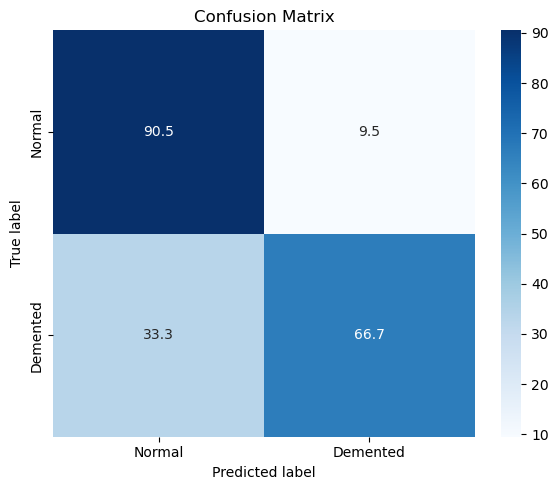

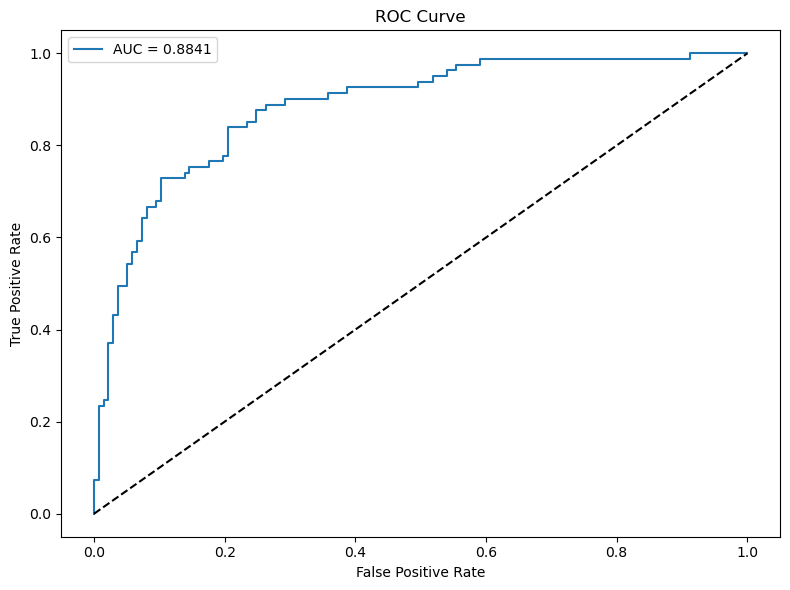

In [18]:
# Load best model weights:
final_model.load_state_dict(
    torch.load("best_alzheimer3dcnn_optunaT1.pth", map_location=DEVICE)
)

# Evaluate on the test set:
test_metrics = test_model(final_model, final_test_loader, DEVICE, plot=True, save=True)


## 13 · Export Optuna Results


In [18]:
trials_df = study.trials_dataframe()
trials_df.to_csv("optuna_trials.csv", index=False)
print("Saved optuna_trials.csv")
display(trials_df.sort_values("value", ascending=False).head(10))


Saved optuna_trials.csv


,number,value,datetime_start,datetime_complete,duration,params_base_channels,params_batch_size,params_dropout,params_fc_units,params_lr,params_n_blocks,params_n_fc_layers,state
6,6,0.608344,2026-06-09 21:35:31.741934,2026-06-09 21:37:45.657833,0 days 00:02:13.915899,32,4,0.330245,384,0.000126,4,1,COMPLETE
22,22,0.606983,2026-06-09 22:09:51.024989,2026-06-09 22:12:12.366198,0 days 00:02:21.341209,32,4,0.529085,384,0.000135,4,0,COMPLETE
24,24,0.528633,2026-06-09 22:12:39.221805,2026-06-09 22:14:59.803851,0 days 00:02:20.582046,32,4,0.457374,384,0.000153,4,0,COMPLETE
10,10,0.527445,2026-06-09 21:44:30.394631,2026-06-09 21:46:44.341250,0 days 00:02:13.946619,32,4,0.568175,320,0.000134,3,0,COMPLETE
12,12,0.526807,2026-06-09 21:47:11.214871,2026-06-09 21:49:25.111884,0 days 00:02:13.897013,32,4,0.597839,384,0.000104,4,0,COMPLETE
25,25,0.519147,2026-06-09 22:14:59.804208,2026-06-09 22:17:14.345985,0 days 00:02:14.541777,32,4,0.448857,384,0.000185,4,0,COMPLETE
13,13,0.516396,2026-06-09 21:49:25.112257,2026-06-09 21:51:39.064131,0 days 00:02:13.951874,32,4,0.508838,256,0.000310,3,1,COMPLETE
27,27,0.510226,2026-06-09 22:17:41.214346,2026-06-09 22:19:54.960271,0 days 00:02:13.745925,32,4,0.516372,448,0.000367,4,0,COMPLETE
7,7,0.491207,2026-06-09 21:37:45.658191,2026-06-09 21:40:01.598170,0 days 00:02:15.939979,32,8,0.242656,448,0.000416,3,1,COMPLETE
16,16,0.471596,2026-06-09 21:54:21.337470,2026-06-09 21:56:36.389804,0 days 00:02:15.052334,32,2,0.468181,512,0.000173,4,0,COMPLETE


Young test subset: Age < 75
Number of subjects: 151

Class distribution:
label
Normal      116
Demented     35
Name: count, dtype: int64

Class distribution (%):
label
Normal      76.821192
Demented    23.178808
Name: proportion, dtype: float64

Age mean : 65.7
Age std  : 6.8
Age range: 45.8 - 74.7

===== TEST METRICS =====
Accuracy           : 0.8477
Macro Precision    : 0.8081
Weighted Precision : 0.8392
Macro Recall       : 0.7313
Weighted Recall    : 0.8477
Macro F1-score     : 0.7578
Weighted F1-score  : 0.8369
ROC AUC            : 0.8650

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal     0.8661    0.9483    0.9053       116
    Demented     0.7500    0.5143    0.6102        35

    accuracy                         0.8477       151
   macro avg     0.8081    0.7313    0.7578       151
weighted avg     0.8392    0.8477    0.8369       151



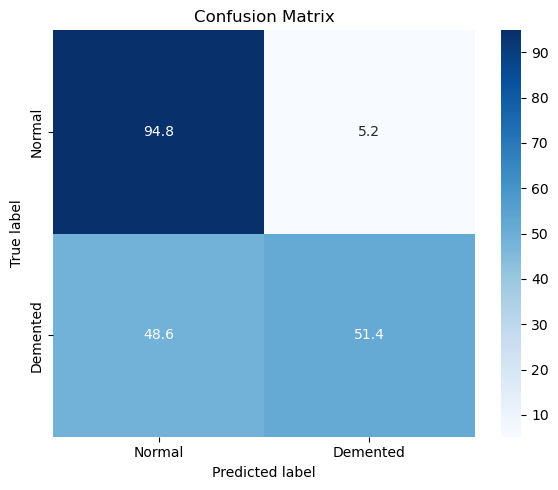

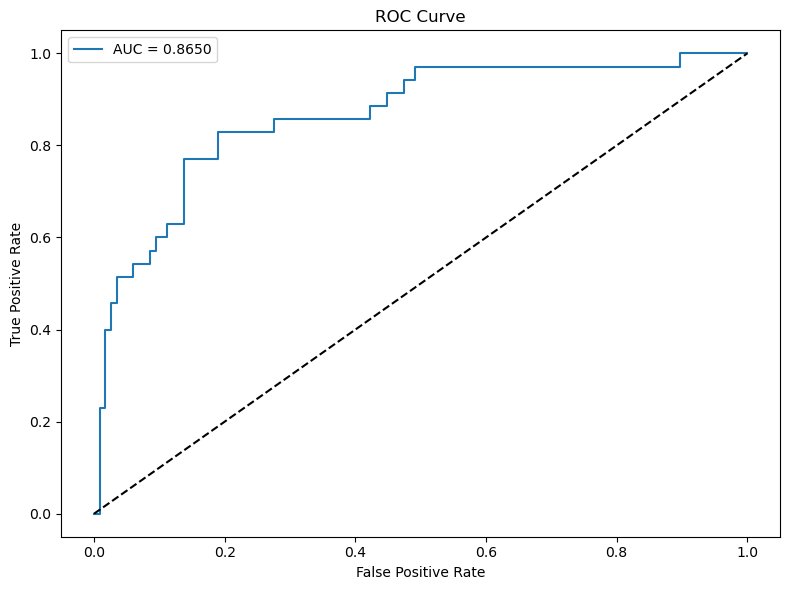


===== YOUNG TEST METRICS DICT =====
{'accuracy': 0.847682119205298, 'precision_macro': 0.8080708661417323, 'precision_weighted': 0.8392214632111383, 'recall_macro': 0.7312807881773399, 'recall_weighted': 0.847682119205298, 'f1_macro': 0.7577596428820534, 'f1_weighted': 0.8369305187753447, 'auc': 0.8650246305418718, 'confusion_matrix': array([[110,   6],
       [ 17,  18]])}


In [19]:
from torch.utils.data import DataLoader

# =========================================================
# Young Subject Subgroup Analysis
# =========================================================

AGE_THRESHOLD = 75

# Filter only young subjects from the original test set
young_test_df = test_df[test_df["Age"] < AGE_THRESHOLD].copy()

print("=" * 55)
print(f"Young test subset: Age < {AGE_THRESHOLD}")
print("=" * 55)

print(f"Number of subjects: {len(young_test_df)}")
print("\nClass distribution:")
print(young_test_df["label"].value_counts().rename({0: "Normal", 1: "Demented"}))

print("\nClass distribution (%):")
print((young_test_df["label"].value_counts(normalize=True) * 100).rename({0: "Normal", 1: "Demented"}))

print(f"\nAge mean : {young_test_df['Age'].mean():.1f}")
print(f"Age std  : {young_test_df['Age'].std():.1f}")
print(f"Age range: {young_test_df['Age'].min():.1f} - {young_test_df['Age'].max():.1f}")

# Create DataLoader for young test subjects
young_test_loader = DataLoader(
    OASIS3DDataset(young_test_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Evaluate model on young test subset
young_test_metrics = test_model(
    final_model,
    young_test_loader,
    DEVICE,
    plot=True,
    save=True
)

print("\n===== YOUNG TEST METRICS DICT =====")
print(young_test_metrics)